# 06 – Logistic Regression

This notebook develops and evaluates baseline and hyperparameter-tuned Logistic Regression models for predicting waterborne disease risk as Low, Medium or High.

Both models are assessed using the same evaluation methods to support a fair comparison with Decision Tree, Random Forest, and XGBoost.

In [1]:
# Import the libraries required for data loading, model training, evaluation, tuning, visualisation and model saving

from pathlib import Path
import time

import joblib
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.preprocessing import label_binarize

In [2]:
# Define the locations of the prepared datasets, model files and result files

DATA_PATH = Path("../data/model_input")
MODEL_PATH = Path("../models")
RESULTS_PATH = MODEL_PATH / "results"

# Create the required folders if they do not already exist

MODEL_PATH.mkdir(parents=True, exist_ok=True)
RESULTS_PATH.mkdir(parents=True, exist_ok=True)

# Display the resolved folder locations for verification

print("Data folder:", DATA_PATH.resolve())
print("Model folder:", MODEL_PATH.resolve())
print("Results folder:", RESULTS_PATH.resolve())

Data folder: C:\Users\ASUS\Desktop\ICBT Assignments\1. New Batch Assignments\Final Project\Final_Project\data\model_input
Model folder: C:\Users\ASUS\Desktop\ICBT Assignments\1. New Batch Assignments\Final Project\Final_Project\models
Results folder: C:\Users\ASUS\Desktop\ICBT Assignments\1. New Batch Assignments\Final Project\Final_Project\models\results


In [3]:
# Load the feature datasets prepared in the Feature Engineering notebook

X_train = pd.read_csv(
    DATA_PATH / "X_train.csv"
)

X_test = pd.read_csv(
    DATA_PATH / "X_test.csv"
)

# Load the target datasets and convert each one-column DataFrame into a Series

y_train = pd.read_csv(
    DATA_PATH / "y_train.csv"
).squeeze("columns")

y_test = pd.read_csv(
    DATA_PATH / "y_test.csv"
).squeeze("columns")

# Display the shapes to confirm that all files were loaded correctly

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (2400, 38)
X_test shape: (600, 38)
y_train shape: (2400,)
y_test shape: (600,)


In [4]:
# Check the number and percentage of Low, Medium and High observations in the training and testing datasets

print("Training class distribution:")
print(y_train.value_counts())

print("\nTraining class percentages:")
print(
    y_train.value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\nTesting class distribution:")
print(y_test.value_counts())

print("\nTesting class percentages:")
print(
    y_test.value_counts(normalize=True)
    .mul(100)
    .round(2)
)

# Display the unique target labels

print("\nTarget classes:")
print(sorted(y_train.unique()))

Training class distribution:
risk_level
Low       807
High      799
Medium    794
Name: count, dtype: int64

Training class percentages:
risk_level
Low       33.62
High      33.29
Medium    33.08
Name: proportion, dtype: float64

Testing class distribution:
risk_level
Low       202
High      200
Medium    198
Name: count, dtype: int64

Testing class percentages:
risk_level
Low       33.67
High      33.33
Medium    33.00
Name: proportion, dtype: float64

Target classes:
['High', 'Low', 'Medium']


In [5]:
# Load the StandardScaler fitted only on the training data in the Feature Engineering notebook

scaler_path = MODEL_PATH / "scaler.pkl"

if not scaler_path.exists():
    raise FileNotFoundError(
        f"The scaler file was not found at: {scaler_path.resolve()}"
    )

scaler = joblib.load(
    scaler_path
)

# Transform the training and testing features using the already-fitted scaler

X_train_scaled = scaler.transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

# Confirm that feature scaling was completed without changing the dataset dimensions

print("Scaler loaded successfully.")
print("Scaled training shape:", X_train_scaled.shape)
print("Scaled testing shape:", X_test_scaled.shape)

Scaler loaded successfully.
Scaled training shape: (2400, 38)
Scaled testing shape: (600, 38)


In [6]:
# Create the baseline Logistic Regression model

baseline_logistic = LogisticRegression(
    random_state=42,
    max_iter=1000
)

print("Baseline Logistic Regression model created successfully.")

Baseline Logistic Regression model created successfully.


In [7]:
# Train the baseline Logistic Regression model and record the training time

start_time = time.time()

baseline_logistic.fit(
    X_train_scaled,
    y_train
)

baseline_training_time = time.time() - start_time

print(f"Training completed in {baseline_training_time:.4f} seconds.")

Training completed in 0.0356 seconds.


In [8]:
# Generate predictions using the trained baseline Logistic Regression model

baseline_train_predictions = baseline_logistic.predict(
    X_train_scaled
)

baseline_test_predictions = baseline_logistic.predict(
    X_test_scaled
)

print("Predictions generated successfully.")

Predictions generated successfully.


In [9]:
# Calculate the evaluation metrics for the baseline Logistic Regression model

train_accuracy = accuracy_score(
    y_train,
    baseline_train_predictions
)

test_accuracy = accuracy_score(
    y_test,
    baseline_test_predictions
)

precision = precision_score(
    y_test,
    baseline_test_predictions,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_test,
    baseline_test_predictions,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_test,
    baseline_test_predictions,
    average="weighted",
    zero_division=0
)

generalisation_gap = train_accuracy - test_accuracy

In [10]:
# Display the evaluation results of the baseline Logistic Regression model

print("=" * 50)
print("Baseline Logistic Regression Performance")
print("=" * 50)

print(f"Training Accuracy : {train_accuracy:.4f}")
print(f"Testing Accuracy  : {test_accuracy:.4f}")
print(f"Precision         : {precision:.4f}")
print(f"Recall            : {recall:.4f}")
print(f"F1-Score          : {f1:.4f}")
print(f"Training Time (s) : {baseline_training_time:.4f}")
print(f"Generalisation Gap: {generalisation_gap:.4f}")

Baseline Logistic Regression Performance
Training Accuracy : 0.8875
Testing Accuracy  : 0.8633
Precision         : 0.8638
Recall            : 0.8633
F1-Score          : 0.8635
Training Time (s) : 0.0356
Generalisation Gap: 0.0242


In [11]:
# Display the classification report for the baseline Logistic Regression model

print(classification_report(
    y_test,
    baseline_test_predictions,
    digits=4,
    zero_division=0
))

              precision    recall  f1-score   support

        High     0.8861    0.8950    0.8905       200
         Low     0.9141    0.8960    0.9050       202
      Medium     0.7900    0.7980    0.7940       198

    accuracy                         0.8633       600
   macro avg     0.8634    0.8630    0.8632       600
weighted avg     0.8638    0.8633    0.8635       600



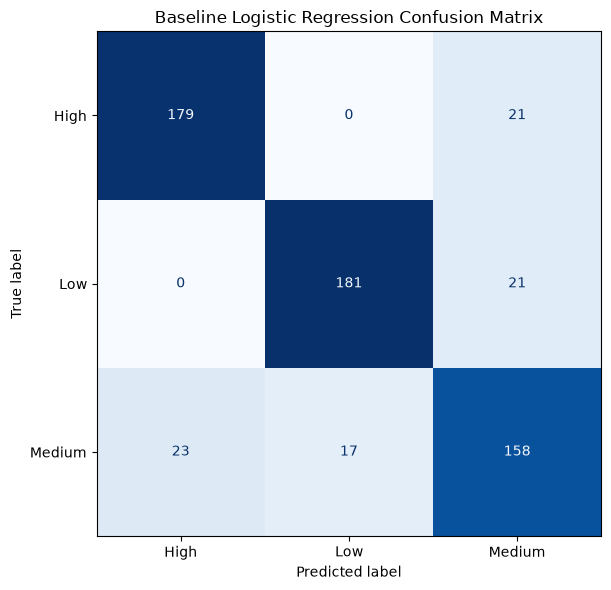

In [12]:
# Display the confusion matrix for the baseline Logistic Regression model

cm = confusion_matrix(
    y_test,
    baseline_test_predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=baseline_logistic.classes_
)

fig, ax = plt.subplots(figsize=(7,6))

disp.plot(
    ax=ax,
    cmap="Blues",
    colorbar=False
)

plt.title("Baseline Logistic Regression Confusion Matrix")
plt.tight_layout()
plt.show()

In [13]:
# Define the hyperparameter values to be tested using GridSearchCV

parameter_grid = [
    {
        "solver": ["lbfgs"],
        "penalty": ["l2"],
        "C": [0.01, 0.1, 1, 10, 100],
        "class_weight": [None, "balanced"]
    },
    {
        "solver": ["saga"],
        "penalty": ["l1", "l2"],
        "C": [0.01, 0.1, 1, 10, 100],
        "class_weight": [None, "balanced"]
    }
]

print("Parameter grid created successfully.")

Parameter grid created successfully.


In [14]:
# Create the GridSearchCV object for Logistic Regression hyperparameter tuning

cross_validation = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid_search = GridSearchCV(
    estimator=LogisticRegression(
        random_state=42,
        max_iter=1000
    ),
    param_grid=parameter_grid,
    scoring="f1_weighted",
    cv=cross_validation,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

print("GridSearchCV created successfully.")

GridSearchCV created successfully.


In [15]:
# Perform hyperparameter tuning using GridSearchCV

start_time = time.time()

grid_search.fit(
    X_train_scaled,
    y_train
)

tuning_time = time.time() - start_time

print(f"GridSearchCV completed in {tuning_time:.2f} seconds.")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
GridSearchCV completed in 10.45 seconds.


c:\Users\ASUS\Desktop\ICBT Assignments\1. New Batch Assignments\Final Project\Final_Project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


In [16]:
# Display the best hyperparameters identified by GridSearchCV

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross Validation Score:")
print(round(grid_search.best_score_, 4))

Best Parameters:
{'C': 10, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'lbfgs'}

Best Cross Validation Score:
0.878


In [17]:
# Retrieve the best Logistic Regression model from GridSearchCV

tuned_logistic = grid_search.best_estimator_

print("Tuned Logistic Regression model created successfully.")

Tuned Logistic Regression model created successfully.


In [18]:
# Generate predictions using the tuned Logistic Regression model

tuned_train_predictions = tuned_logistic.predict(
    X_train_scaled
)

tuned_test_predictions = tuned_logistic.predict(
    X_test_scaled
)

print("Predictions generated successfully.")

Predictions generated successfully.


In [19]:
# Calculate the evaluation metrics for the tuned Logistic Regression model

tuned_train_accuracy = accuracy_score(
    y_train,
    tuned_train_predictions
)

tuned_test_accuracy = accuracy_score(
    y_test,
    tuned_test_predictions
)

tuned_precision = precision_score(
    y_test,
    tuned_test_predictions,
    average="weighted",
    zero_division=0
)

tuned_recall = recall_score(
    y_test,
    tuned_test_predictions,
    average="weighted",
    zero_division=0
)

tuned_f1 = f1_score(
    y_test,
    tuned_test_predictions,
    average="weighted",
    zero_division=0
)

tuned_generalisation_gap = (
    tuned_train_accuracy -
    tuned_test_accuracy
)

In [20]:
# Display the evaluation results of the tuned Logistic Regression model

print("=" * 50)
print("Tuned Logistic Regression Performance")
print("=" * 50)

print(f"Training Accuracy : {tuned_train_accuracy:.4f}")
print(f"Testing Accuracy  : {tuned_test_accuracy:.4f}")
print(f"Precision         : {tuned_precision:.4f}")
print(f"Recall            : {tuned_recall:.4f}")
print(f"F1-Score          : {tuned_f1:.4f}")
print(f"Training Time (s) : {tuning_time:.4f}")
print(f"Generalisation Gap: {tuned_generalisation_gap:.4f}")

Tuned Logistic Regression Performance
Training Accuracy : 0.8883
Testing Accuracy  : 0.8600
Precision         : 0.8614
Recall            : 0.8600
F1-Score          : 0.8605
Training Time (s) : 10.4484
Generalisation Gap: 0.0283


In [21]:
# Display the classification report for the tuned Logistic Regression model

print("=" * 50)
print("Tuned Logistic Regression Classification Report")
print("=" * 50)

print(
    classification_report(
        y_test,
        tuned_test_predictions,
        digits=4,
        zero_division=0
    )
)

Tuned Logistic Regression Classification Report
              precision    recall  f1-score   support

        High     0.8905    0.8950    0.8928       200
         Low     0.9128    0.8812    0.8967       202
      Medium     0.7794    0.8030    0.7910       198

    accuracy                         0.8600       600
   macro avg     0.8609    0.8597    0.8602       600
weighted avg     0.8614    0.8600    0.8605       600



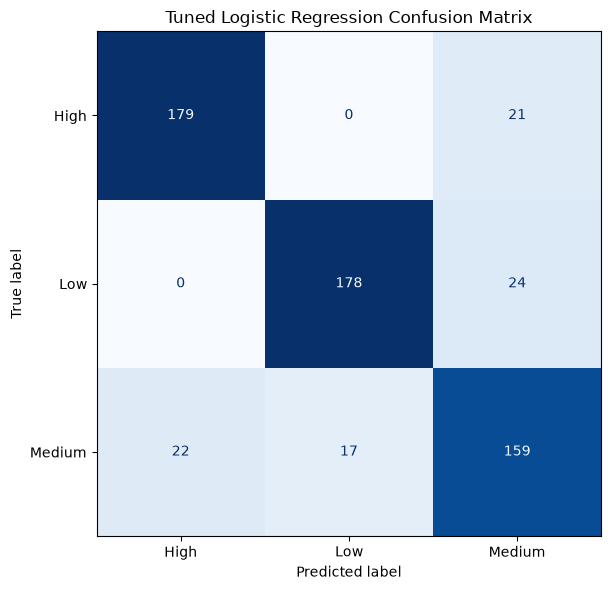

In [22]:
# Display the confusion matrix for the tuned Logistic Regression model

tuned_confusion_matrix = confusion_matrix(
    y_test,
    tuned_test_predictions
)

display = ConfusionMatrixDisplay(
    confusion_matrix=tuned_confusion_matrix,
    display_labels=tuned_logistic.classes_
)

fig, ax = plt.subplots(figsize=(7, 6))

display.plot(
    ax=ax,
    colorbar=False,
    cmap="Blues"
)

plt.title("Tuned Logistic Regression Confusion Matrix")
plt.tight_layout()
plt.show()

In [23]:
# Compare the baseline and tuned Logistic Regression models

comparison_results = pd.DataFrame({
    "Model": [
        "Baseline Logistic Regression",
        "Tuned Logistic Regression"
    ],
    "Training Accuracy": [
        train_accuracy,
        tuned_train_accuracy
    ],
    "Testing Accuracy": [
        test_accuracy,
        tuned_test_accuracy
    ],
    "Precision": [
        precision,
        tuned_precision
    ],
    "Recall": [
        recall,
        tuned_recall
    ],
    "F1-Score": [
        f1,
        tuned_f1
    ],
    "Generalisation Gap": [
        generalisation_gap,
        tuned_generalisation_gap
    ]
})

comparison_results = comparison_results.round(4)

comparison_results

,Model,Training Accuracy,Testing Accuracy,Precision,Recall,F1-Score,Generalisation Gap
0,Baseline Logistic Regression,0.8875,0.8633,0.8638,0.8633,0.8635,0.0242
1,Tuned Logistic Regression,0.8883,0.8600,0.8614,0.8600,0.8605,0.0283


In [24]:
# Select the better Logistic Regression model based on the F1-Score

if tuned_f1 > f1:
    final_logistic_model = tuned_logistic
    selected_model = "Tuned Logistic Regression"
else:
    final_logistic_model = baseline_logistic
    selected_model = "Baseline Logistic Regression"

print(f"Selected Model: {selected_model}")

Selected Model: Baseline Logistic Regression


In [25]:
# Save the baseline and tuned Logistic Regression models

joblib.dump(
    baseline_logistic,
    MODEL_PATH / "logistic_regression_baseline.pkl"
)

joblib.dump(
    tuned_logistic,
    MODEL_PATH / "logistic_regression_tuned.pkl"
)

print("Baseline and tuned models saved successfully.")

Baseline and tuned models saved successfully.


In [26]:
# Save the Logistic Regression comparison results

comparison_results.to_csv(
    RESULTS_PATH / "logistic_regression_results.csv",
    index=False
)

print("Comparison results saved successfully.")

Comparison results saved successfully.


In [27]:
# Save the GridSearchCV results for future reference

grid_search_results = pd.DataFrame(
    grid_search.cv_results_
)

grid_search_results.to_csv(
    RESULTS_PATH / "logistic_regression_grid_search_results.csv",
    index=False
)

print("GridSearchCV results saved successfully.")

GridSearchCV results saved successfully.


In [28]:
# Save the best hyperparameters identified by GridSearchCV

joblib.dump(
    grid_search.best_params_,
    RESULTS_PATH / "logistic_regression_best_parameters.pkl"
)

print("Best hyperparameters saved successfully.")

Best hyperparameters saved successfully.


In [29]:
# Verify that all Logistic Regression files were saved successfully

files_to_check = [
    MODEL_PATH / "logistic_regression_baseline.pkl",
    MODEL_PATH / "logistic_regression_tuned.pkl",
    RESULTS_PATH / "logistic_regression_results.csv",
    RESULTS_PATH / "logistic_regression_grid_search_results.csv",
    RESULTS_PATH / "logistic_regression_best_parameters.pkl"
]

print("=" * 60)
print("Generated Files")
print("=" * 60)

for file in files_to_check:
    print(f"{file.name:<50} {file.exists()}")

Generated Files
logistic_regression_baseline.pkl                   True
logistic_regression_tuned.pkl                      True
logistic_regression_results.csv                    True
logistic_regression_grid_search_results.csv        True
logistic_regression_best_parameters.pkl            True


In [30]:
# Display the selected Logistic Regression model

print("=" * 60)
print("Final Logistic Regression Model Selection")
print("=" * 60)

print(f"Selected Model : {selected_model}")
print(f"Testing Accuracy : {test_accuracy:.4f}" if selected_model == "Baseline Logistic Regression" else f"Testing Accuracy : {tuned_test_accuracy:.4f}")
print(f"F1-Score : {f1:.4f}" if selected_model == "Baseline Logistic Regression" else f"F1-Score : {tuned_f1:.4f}")

print("\nReason:")
print("The selected model achieved the better overall performance on the independent test dataset.")

Final Logistic Regression Model Selection
Selected Model : Baseline Logistic Regression
Testing Accuracy : 0.8633
F1-Score : 0.8635

Reason:
The selected model achieved the better overall performance on the independent test dataset.
